# Woche 1 – Donnerstag: Wiederholung & Pandas

## Block 1 (06:00 – 08:45): Algorithmische Metrik-Verifikation

**Lernziel:** Sie können die Axiome einer Metrik algorithmisch prüfen und relationale Abhängigkeiten zu Normen und Vektorräumen herstellen.

### 1.1 Theoretische Synthese
1. **Mindmap (STEM):** Modellieren Sie den Graphen: *Vektorraum → (ausgestattet mit Norm) → Normierter Raum → (induziert Metrik) → Metrischer Raum*.
2. **Schriftliche Analyse:** Lösen Sie MIDS‑Aufgaben 8.1 und 8.2 (Fokus auf Gegenbeweise bei verletzten Axiomen).

### 1.2 Algorithmische Implementierung
Implementieren Sie einen toleranzbasierten Tester für Metriken und verifizieren Sie diesen maschinell.


In [2]:
import numpy as np

def is_metric(d_func, points, tol=1e-8):
    """Prüft eine Distanzfunktion approximativ auf die drei Metrik-Axiome."""
    n = len(points)
    for i in range(n):
        for j in range(n):
            dist = d_func(points[i], points[j])
            
            # 1. Positive Definitheit
            if i == j:
                if abs(dist) > tol: return False
            else:
                if dist <= tol: return False
                
            # 2. Symmetrie
            if abs(dist - d_func(points[j], points[i])) > tol: return False
            
            # 3. Dreiecksungleichung
            for k in range(n):
                if dist > d_func(points[i], points[k]) + d_func(points[k], points[j]) + tol:
                    return False
    return True

# Verifikation (Test-Driven)
pts = [np.array([0,0]), np.array([3,4]), np.array([1,1])]

# L2-Norm induziert eine gültige Metrik
d_euklid = lambda x, y: np.linalg.norm(x - y, 2)
assert is_metric(d_euklid, pts) == True, "Fehler: Euklidische Distanz ist eine Metrik."

# Quadrierte L2-Norm ist KEINE Metrik (verletzt Dreiecksungleichung)
d_falsch = lambda x, y: np.linalg.norm(x - y, 2) ** 2
assert is_metric(d_falsch, pts) == False, "Fehler: Quadrierte Distanz darf keine Metrik sein."

## Block 2 (09:30 – 11:40): Pandas – Data Engineering (AML-Batch)

**Lernziel:** Lernziel: Sie können JSON-Datenstrukturen sicher in DataFrames überführen, die Datenintegrität maschinell prüfen und aggregierte Statistiken visualisieren.

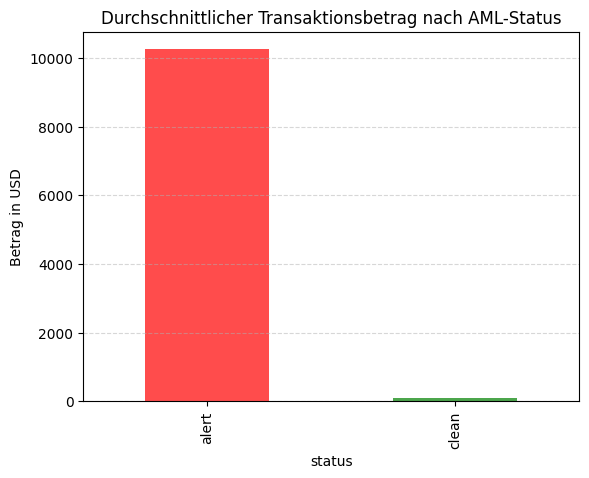

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Daten laden (mit Fallback auf Mock-Daten für Reproduzierbarkeit)
try:
    df = pd.read_json('cleaned_aml_batch.json')
except FileNotFoundError:
    # Reproduzierbarer Fallback-Datensatz
    df = pd.DataFrame({
        'tx_id': [101, 102, 103, 104],
        'amount': [150.0, 12000.0, 45.0, 8500.0],
        'status': ['clean', 'alert', 'clean', 'alert']
    })

# 2. Maschinelle Datenintegritätsprüfung (Pipeline-Standard)
assert not df.empty, "Kritischer Fehler: DataFrame ist leer."
assert 'amount' in df.columns and 'status' in df.columns, "Kritische Features fehlen."
assert df['amount'].dtype == 'float64', "Betrag muss numerisch sein."

# 3. Aggregation
grouped_status = df.groupby('status')['amount'].mean()

# 4. Explorative Datenanalyse (Visualisierung)
grouped_status.plot(kind='bar', color=['red', 'green'], alpha=0.7)
plt.title('Durchschnittlicher Transaktionsbetrag nach AML-Status')
plt.ylabel('Betrag in USD')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Block 3 (12:40 – 14:10): Compliance-Differenzierung (Art. 4 vs. Art. 6)

**Lernziel:** Sie können den universellen Geltungsbereich von Art. 4 (KI-Kompetenz) vom restriktiven Bereich des Art. 6 (Hochrisiko) juristisch abgrenzen.

*Juristischer Kontext:* Artikel 4 gilt für alle KI-Systeme, unabhängig von ihrem Risiko. Die Tiefe der benötigten Kompetenz skaliert jedoch mit dem potenziellen Schaden.

| KI-System | Einstufung | Begründung für Art. 4 (KI-Kompetenz) |
| :--- | :--- | :--- |
| **Kredit-Scoring** | Hochrisiko (Art. 6) | Personal muss Bias-Metriken interpretieren können, um systematische Diskriminierung bei der Kreditvergabe zu verhindern. |
| **AML-Autoencoder** | Hochrisiko (Art. 6) | Analysten müssen *False Positives* mathematisch nachvollziehen können, um ungerechtfertigte Kontosperrungen zu vermeiden. |
| **Service-Chatbot** | Minimales Risiko | Personal muss Halluzinationen (*Confabulations*) erkennen können, um rechtlich bindende Falschaussagen gegenüber Kunden abzuwenden. |

---

## Block 4 (14:40 – 16:50): C2-Schreibübung (Management-Memo)

**Lernziel:** Sie können rechtliche Handlungsbedarfe an das Top-Management adressieren. Dabei maximieren Sie die Informationsdichte durch den obligatorischen Einsatz des Nominalstils und funktionaler Passiversatzformen.

**Aufgabe:** Verfassen Sie ein internes Memo an die Geschäftsleitung der „Deutsche FinTech AG“ (max. 200 Wörter).

**Speicherort:** `01_Master_Curriculum_DS_ML/Track_C_Governance_and_Compliance/02_memo_ki_kompetenz.md`

**Grammatikalische Restriktionen:**

1. **Nominalstil:** Wandeln Sie verbale Beschreibungen von Maßnahmen in Substantive um (z. B. *„Wir müssen die Mitarbeiter schulen“* → *„Die Durchführung von Mitarbeiterschulungen ist obligatorisch“*).
   
2. **Passiversatzformen:** Verwenden Sie exakt einmal die Konstruktion *„sein + zu + Infinitiv“* (für eine Pflicht) und einmal *„sich lassen + Infinitiv“* (für eine Machbarkeit).

**Gliederungsvorgabe:**
1. Regulatorischer Trigger (Art. 4 AI Act)
2. Risikobewertung des AML-Autoencoders
3. Umsetzungsstrategie (Kompetenzaufbau)